# Vergleichende Kraftstoffpreis-Prognose: Europa vs. Indonesien

**Wöchentliche Kraftstoffpreise 2020–2026 | Deutschland, Frankreich, Indonesien**

---

## Zentrale Ergebnisse

1. **Deutschland und Frankreich** zeigen starke Preiskointegration – typisch für integrierte europäische Märkte mit marktgetriebener Preisbildung.
2. **Indonesien** weist ein strukturell anderes Preisregime auf: niedrigere Preise, geringere Volatilität und schwächere Brent-Durchreichung aufgrund staatlicher Subventionen.
3. **Kurzfrist-Prognosen (6–8 Wochen)** liefern deutlich bessere Ergebnisse als Langfrist-Prognosen – besonders bei klassischen Modellen.
4. **Klassische Modelle (ARIMA, State Space)** liefern starke Ergebnisse – insbesondere bei stabilen, subventionierten Märkten.

---

## Inhaltsverzeichnis

1. [Setup & Konfiguration](#setup)
2. [Daten laden & Überblick](#daten)
3. [Explorative Datenanalyse (EDA)](#eda)
4. [Stationaritätstests](#stationaritaet)
5. [Modellierung](#modellierung)
   - 5.1 ARIMA
   - 5.2 VAR
   - 5.3 Granger-Kausalität
   - 5.4 State Space / Unobserved Components
   - 5.5 Globales VAR (alle 3 Laender)
6. [Modellvergleich & Evaluation](#evaluation)
7. [Analytische Diskussion](#diskussion)
8. [Fazit](#fazit)

<a id='setup'></a>
## 1. Setup & Konfiguration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.api import VAR
from statsmodels.tsa.statespace.structural import UnobservedComponents
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

sns.set_theme(style='whitegrid', palette='colorblind', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

PLOT_DIR = Path('../docs/plots')
PLOT_DIR.mkdir(parents=True, exist_ok=True)

COUNTRIES = ['Germany', 'France', 'Indonesia']
COUNTRY_COLORS = {'Germany': '#1f77b4', 'France': '#ff7f0e', 'Indonesia': '#2ca02c'}
COUNTRY_LABELS = {'Germany': 'Deutschland', 'France': 'Frankreich', 'Indonesia': 'Indonesien'}

FORECAST_HORIZON = 8  # Wochen
TARGET_COL = 'petrol_usd_liter'

print('Setup abgeschlossen.')

Setup abgeschlossen.


<a id='daten'></a>
## 2. Daten laden & Überblick

In [2]:
data = {}
for country in COUNTRIES:
    df = pd.read_csv(f'../data/processed/fuel_prices_{country}.csv', parse_dates=['date'])
    df = df.sort_values('date').reset_index(drop=True)
    df = df.set_index('date')
    df.index.freq = 'W-MON'
    data[country] = df
    print(f'{COUNTRY_LABELS[country]}: {len(df)} Beobachtungen, '
          f'{df.index.min().date()} bis {df.index.max().date()}')

print(f'\nSpalten: {list(data["Germany"].columns)}')

Deutschland: 327 Beobachtungen, 2020-01-06 bis 2026-04-06
Frankreich: 327 Beobachtungen, 2020-01-06 bis 2026-04-06
Indonesien: 327 Beobachtungen, 2020-01-06 bis 2026-04-06

Spalten: ['country', 'region', 'income_level', 'subsidy_level', 'petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter', 'brent_crude_usd', 'tax_percentage']


In [3]:
for country in COUNTRIES:
    print(f'\n=== {COUNTRY_LABELS[country]} ===')
    display(data[country][['petrol_usd_liter', 'diesel_usd_liter', 'brent_crude_usd', 'tax_percentage']].describe().round(3))


=== Deutschland ===


,petrol_usd_liter,diesel_usd_liter,brent_crude_usd,tax_percentage
count,327.000,327.000,327.000,327.000
mean,4.208,3.989,106.686,39.213
std,0.751,0.711,19.001,15.945
min,1.921,1.810,47.970,10.200
25%,3.974,3.776,101.160,26.200
50%,4.442,4.197,112.270,39.800
75%,4.704,4.452,119.385,52.400
max,5.155,4.889,130.000,65.000



=== Frankreich ===


,petrol_usd_liter,diesel_usd_liter,brent_crude_usd,tax_percentage
count,327.000,327.000,327.000,327.000
mean,4.166,4.099,106.686,36.931
std,0.741,0.731,19.001,15.499
min,1.903,1.847,47.970,10.200
25%,3.944,3.883,101.160,24.200
50%,4.378,4.319,112.270,36.600
75%,4.659,4.582,119.385,49.800
max,5.119,5.019,130.000,64.800



=== Indonesien ===


,petrol_usd_liter,diesel_usd_liter,brent_crude_usd,tax_percentage
count,327.000,327.000,327.000,327.000
mean,0.882,0.830,106.686,16.015
std,0.157,0.149,19.001,8.971
min,0.413,0.387,47.970,0.100
25%,0.831,0.784,101.160,8.750
50%,0.931,0.877,112.270,16.000
75%,0.988,0.925,119.385,24.350
max,1.106,1.060,130.000,30.000


<a id='eda'></a>
## 3. Explorative Datenanalyse

### 3.1 Benzinpreis-Vergleich aller Länder

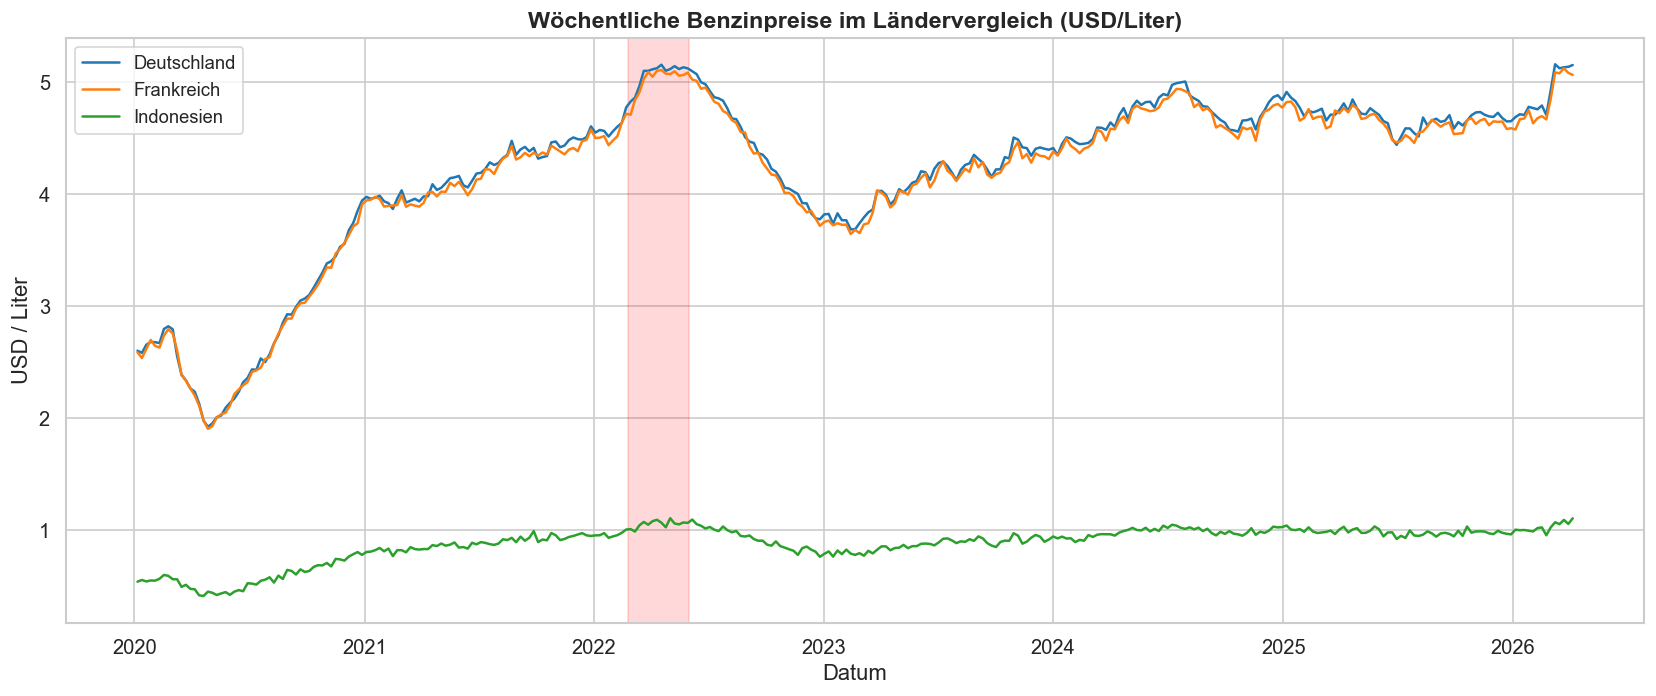

In [4]:
fig, ax = plt.subplots(figsize=(14, 6))
for country in COUNTRIES:
    ax.plot(data[country].index, data[country]['petrol_usd_liter'],
            label=COUNTRY_LABELS[country], color=COUNTRY_COLORS[country], linewidth=1.5)
ax.set_title('Wöchentliche Benzinpreise im Ländervergleich (USD/Liter)', fontsize=14, fontweight='bold')
ax.set_xlabel('Datum')
ax.set_ylabel('USD / Liter')
ax.legend(fontsize=11)
ax.axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2022-06-01'), alpha=0.15, color='red', label='Ukraine-Krise')
plt.tight_layout()
plt.savefig(PLOT_DIR / '01_benzinpreise_vergleich.png')
plt.show()

**Beobachtung:** Deutschland und Frankreich bewegen sich nahezu synchron – typisch für integrierte europäische Märkte. Indonesien liegt auf einem deutlich niedrigeren Preisniveau mit auffällig geringerer Volatilität, bedingt durch das staatliche Subventionssystem.

### 3.2 Diesel-Preisvergleich

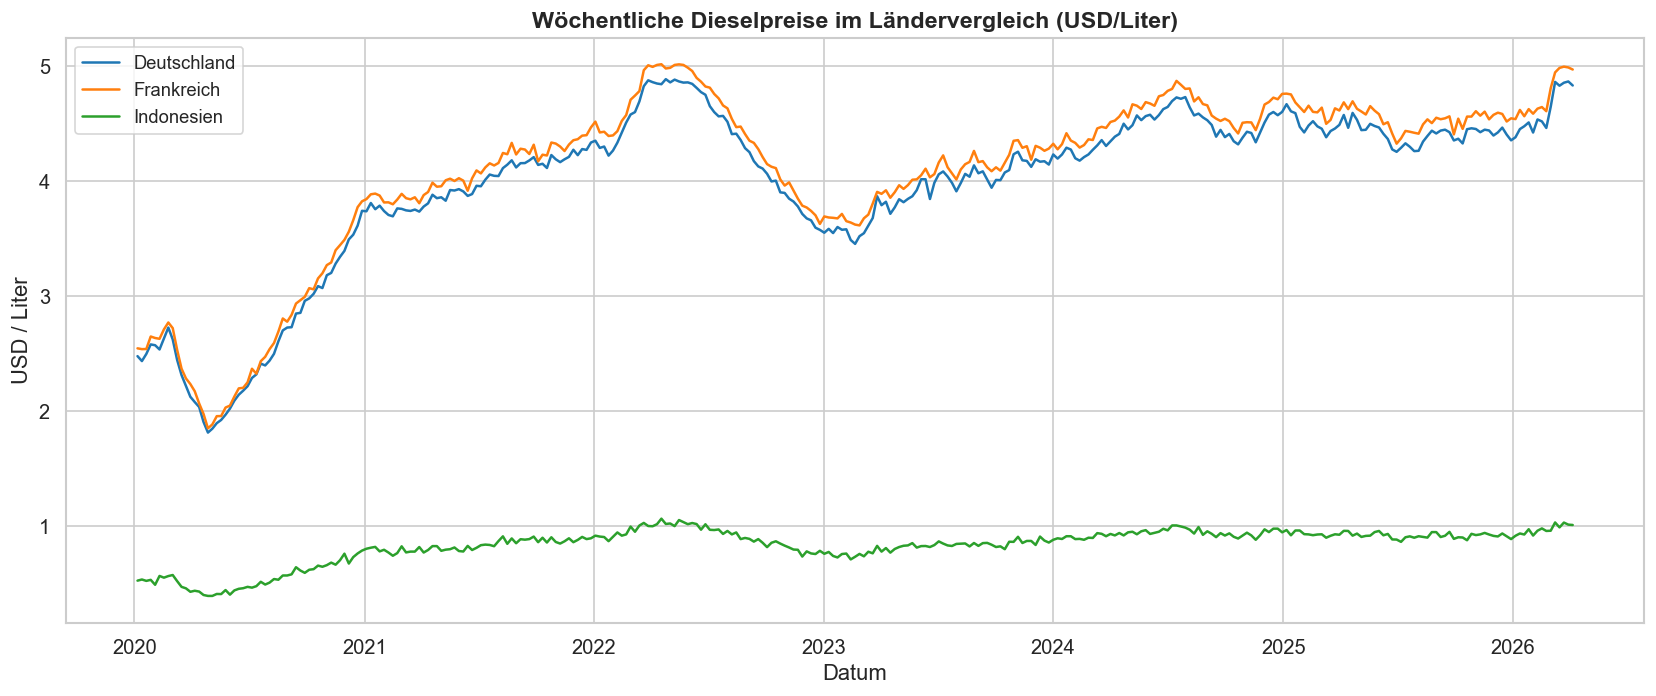

In [5]:
fig, ax = plt.subplots(figsize=(14, 6))
for country in COUNTRIES:
    ax.plot(data[country].index, data[country]['diesel_usd_liter'],
            label=COUNTRY_LABELS[country], color=COUNTRY_COLORS[country], linewidth=1.5)
ax.set_title('Wöchentliche Dieselpreise im Ländervergleich (USD/Liter)', fontsize=14, fontweight='bold')
ax.set_xlabel('Datum')
ax.set_ylabel('USD / Liter')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / '02_dieselpreise_vergleich.png')
plt.show()

### 3.3 Brent-Rohölpreis als gemeinsamer Treiber

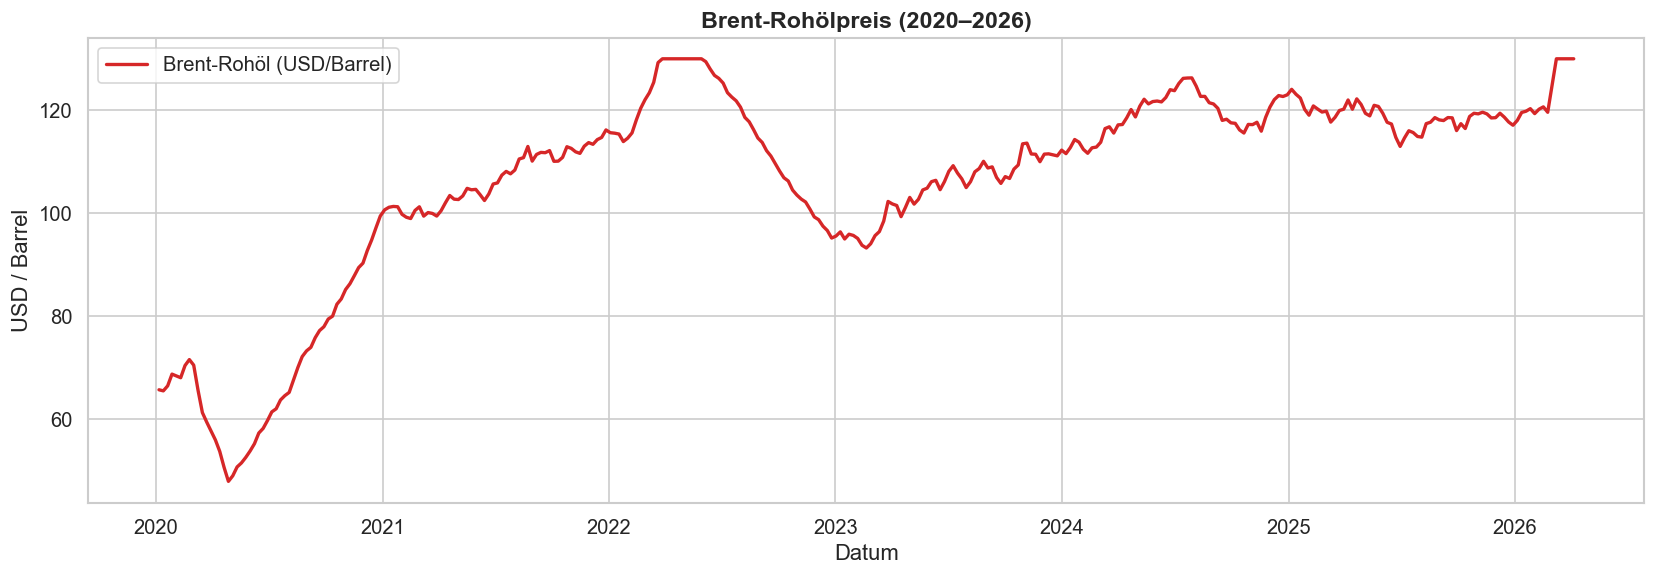

In [6]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(data['Germany'].index, data['Germany']['brent_crude_usd'],
        color='#d62728', linewidth=2, label='Brent-Rohöl (USD/Barrel)')
ax.set_title('Brent-Rohölpreis (2020–2026)', fontsize=14, fontweight='bold')
ax.set_xlabel('Datum')
ax.set_ylabel('USD / Barrel')
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / '03_brent_crude.png')
plt.show()

### 3.4 Volatilitätsvergleich

Die rollierende Standardabweichung (12-Wochen-Fenster) zeigt die unterschiedlichen Volatilitätsregime.

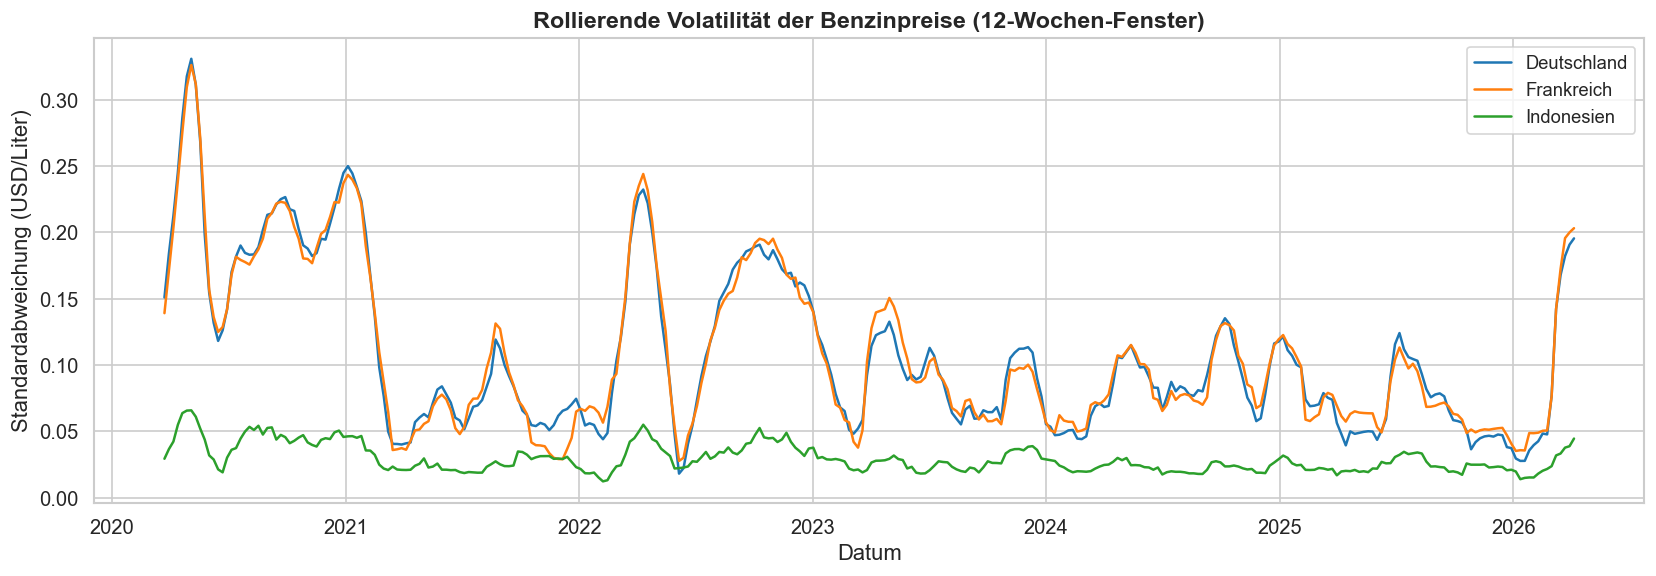

In [7]:
fig, ax = plt.subplots(figsize=(14, 5))
for country in COUNTRIES:
    rolling_std = data[country]['petrol_usd_liter'].rolling(12).std()
    ax.plot(data[country].index, rolling_std,
            label=COUNTRY_LABELS[country], color=COUNTRY_COLORS[country], linewidth=1.5)
ax.set_title('Rollierende Volatilität der Benzinpreise (12-Wochen-Fenster)', fontsize=14, fontweight='bold')
ax.set_xlabel('Datum')
ax.set_ylabel('Standardabweichung (USD/Liter)')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(PLOT_DIR / '04_volatilitaet_vergleich.png')
plt.show()

**Beobachtung:** Die Volatilität in Indonesien ist konstant sehr niedrig – das Subventionssystem dämpft Preisschwankungen effektiv ab. In Europa sehen wir dagegen deutliche Volatilitätsspitzen, insbesondere während der Ukraine-Krise 2022.

### 3.5 Korrelationsanalyse

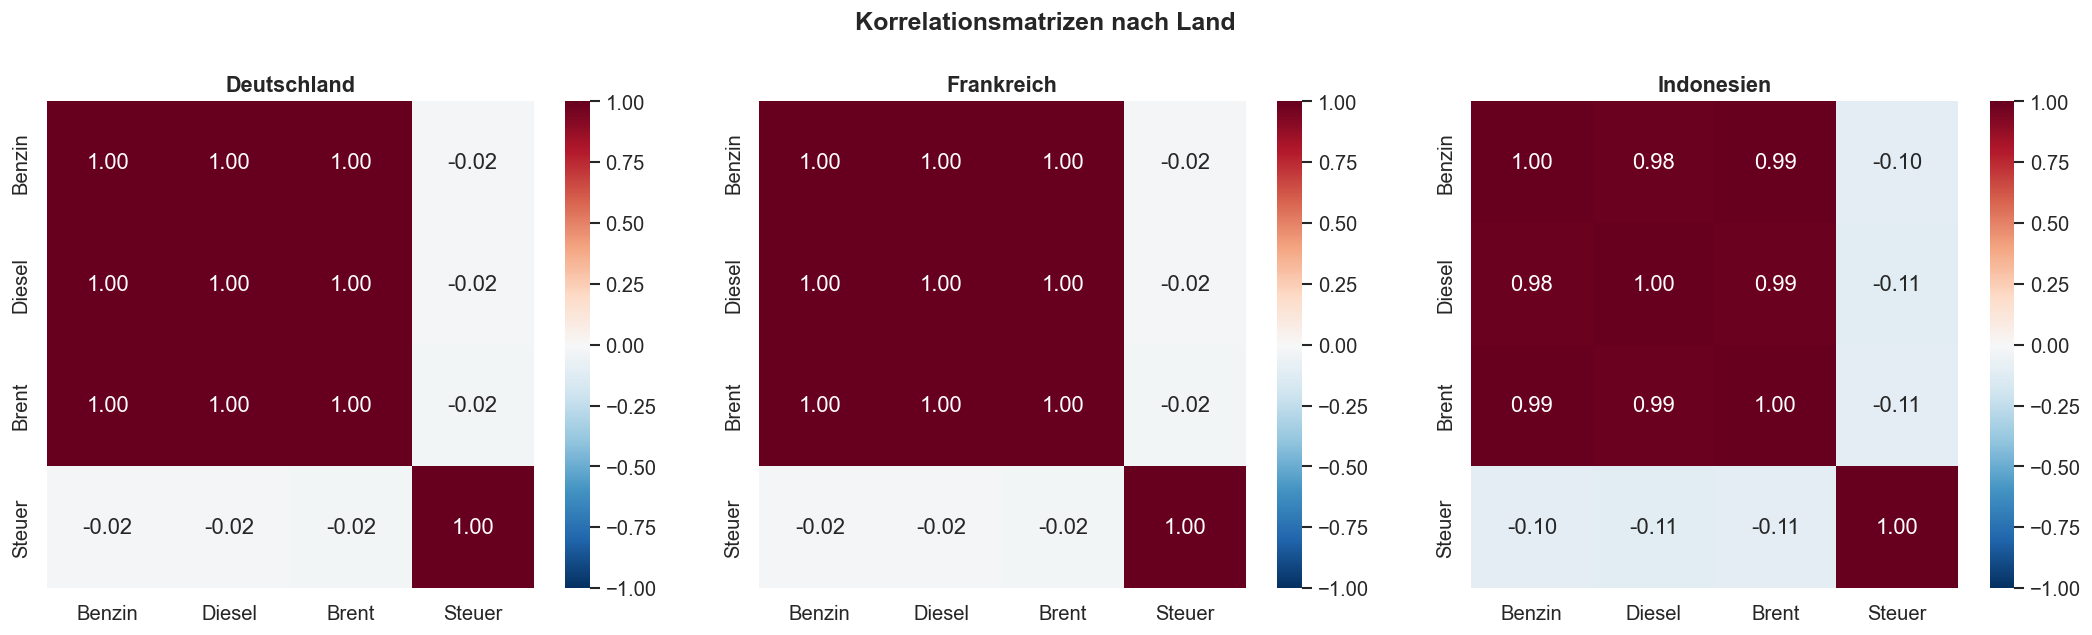

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, country in enumerate(COUNTRIES):
    cols = ['petrol_usd_liter', 'diesel_usd_liter', 'brent_crude_usd', 'tax_percentage']
    corr = data[country][cols].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                ax=axes[i], vmin=-1, vmax=1, square=True,
                xticklabels=['Benzin', 'Diesel', 'Brent', 'Steuer'],
                yticklabels=['Benzin', 'Diesel', 'Brent', 'Steuer'])
    axes[i].set_title(COUNTRY_LABELS[country], fontsize=13, fontweight='bold')
fig.suptitle('Korrelationsmatrizen nach Land', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOT_DIR / '05_korrelation_heatmaps.png')
plt.show()

**Beobachtung:** In Deutschland und Frankreich besteht eine hohe Korrelation zwischen Benzin-/Dieselpreisen und dem Brent-Rohölpreis – der Marktmechanismus funktioniert. In Indonesien ist diese Korrelation schwächer, da staatliche Preissteuerung den Brent-Durchreichungseffekt abschwächt.

### 3.6 Europa vs. Indonesien – Preisniveau-Vergleich

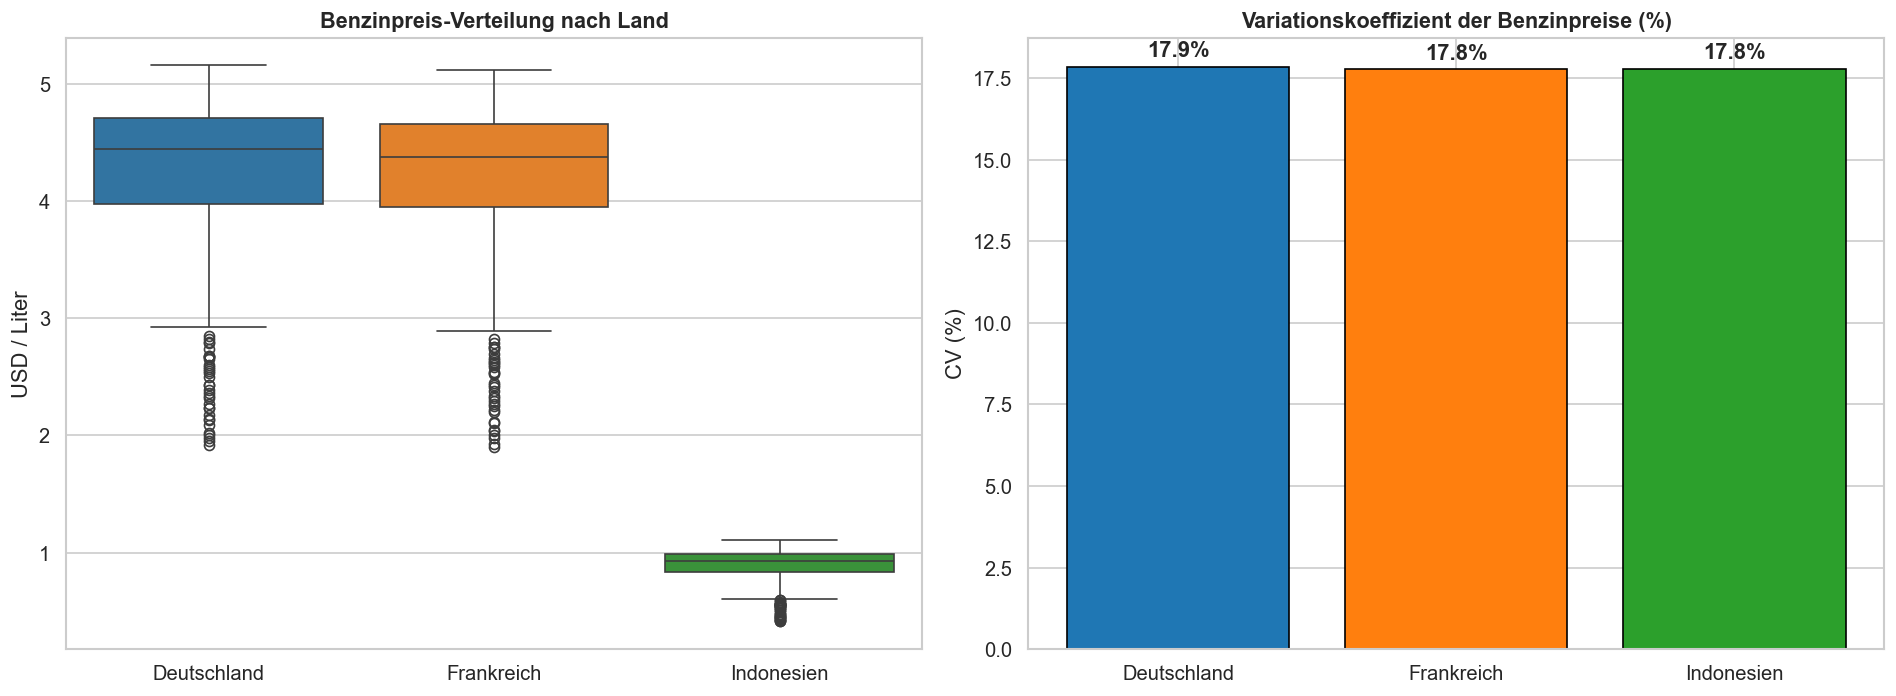

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
box_data = []
for country in COUNTRIES:
    df_temp = data[country][['petrol_usd_liter']].copy()
    df_temp['Land'] = COUNTRY_LABELS[country]
    box_data.append(df_temp)
box_df = pd.concat(box_data)
sns.boxplot(data=box_df, x='Land', y='petrol_usd_liter', palette=COUNTRY_COLORS.values(), ax=axes[0])
axes[0].set_title('Benzinpreis-Verteilung nach Land', fontsize=13, fontweight='bold')
axes[0].set_ylabel('USD / Liter')
axes[0].set_xlabel('')

# Variationskoeffizient
cv_data = {COUNTRY_LABELS[c]: data[c]['petrol_usd_liter'].std() / data[c]['petrol_usd_liter'].mean() * 100
           for c in COUNTRIES}
bars = axes[1].bar(cv_data.keys(), cv_data.values(), color=list(COUNTRY_COLORS.values()), edgecolor='black')
axes[1].set_title('Variationskoeffizient der Benzinpreise (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('CV (%)')
for bar, val in zip(bars, cv_data.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR / '06_europa_vs_indonesien.png')
plt.show()

**Beobachtung:** Trotz niedrigerem absolutem Preisniveau zeigt Indonesien einen vergleichbaren Variationskoeffizienten – relativ zur Preishöhe ist die Preisstreuung also nicht vernachlässigbar. Die Subventionen stabilisieren den *absoluten* Preis, nicht unbedingt die *relative* Preisdynamik.

<a id='stationaritaet'></a>
## 4. Stationaritätstests (ADF-Test)

In [10]:
def adf_test(series, name=''):
    result = adfuller(series.dropna(), autolag='AIC')
    return {
        'Variable': name,
        'ADF-Statistik': round(result[0], 4),
        'p-Wert': round(result[1], 4),
        'Stationär': 'Ja' if result[1] < 0.05 else 'Nein'
    }

adf_results = []
test_cols = ['petrol_usd_liter', 'diesel_usd_liter', 'brent_crude_usd']

for country in COUNTRIES:
    for col in test_cols:
        # Level
        adf_results.append(adf_test(data[country][col],
                                     f'{COUNTRY_LABELS[country]} – {col} (Level)'))
        # Erste Differenz
        adf_results.append(adf_test(data[country][col].diff(),
                                     f'{COUNTRY_LABELS[country]} – {col} (Δ)'))

adf_df = pd.DataFrame(adf_results)
display(adf_df)

,Variable,ADF-Statistik,p-Wert,Stationär
0,Deutschland – petrol_usd_liter (Level),-2.4241,0.1350,Nein
1,Deutschland – petrol_usd_liter (Δ),-5.5171,0.0000,Ja
2,Deutschland – diesel_usd_liter (Level),-1.9762,0.2971,Nein
3,Deutschland – diesel_usd_liter (Δ),-5.4403,0.0000,Ja
4,Deutschland – brent_crude_usd (Level),-1.9594,0.3046,Nein
5,Deutschland – brent_crude_usd (Δ),-5.0646,0.0000,Ja
6,Frankreich – petrol_usd_liter (Level),-1.9772,0.2966,Nein
7,Frankreich – petrol_usd_liter (Δ),-5.5838,0.0000,Ja
8,Frankreich – diesel_usd_liter (Level),-1.7138,0.4240,Nein
9,Frankreich – diesel_usd_liter (Δ),-5.4524,0.0000,Ja


**Interpretation:** Wie bei den meisten makroökonomischen Zeitreihen erwarten wir, dass die Preise auf Level-Ebene nicht stationär sind (Unit Root), die ersten Differenzen jedoch stationär. Dies bestätigt die Notwendigkeit der Differenzierung für ARIMA- und VAR-Modelle.

### ACF / PACF der Benzinpreise

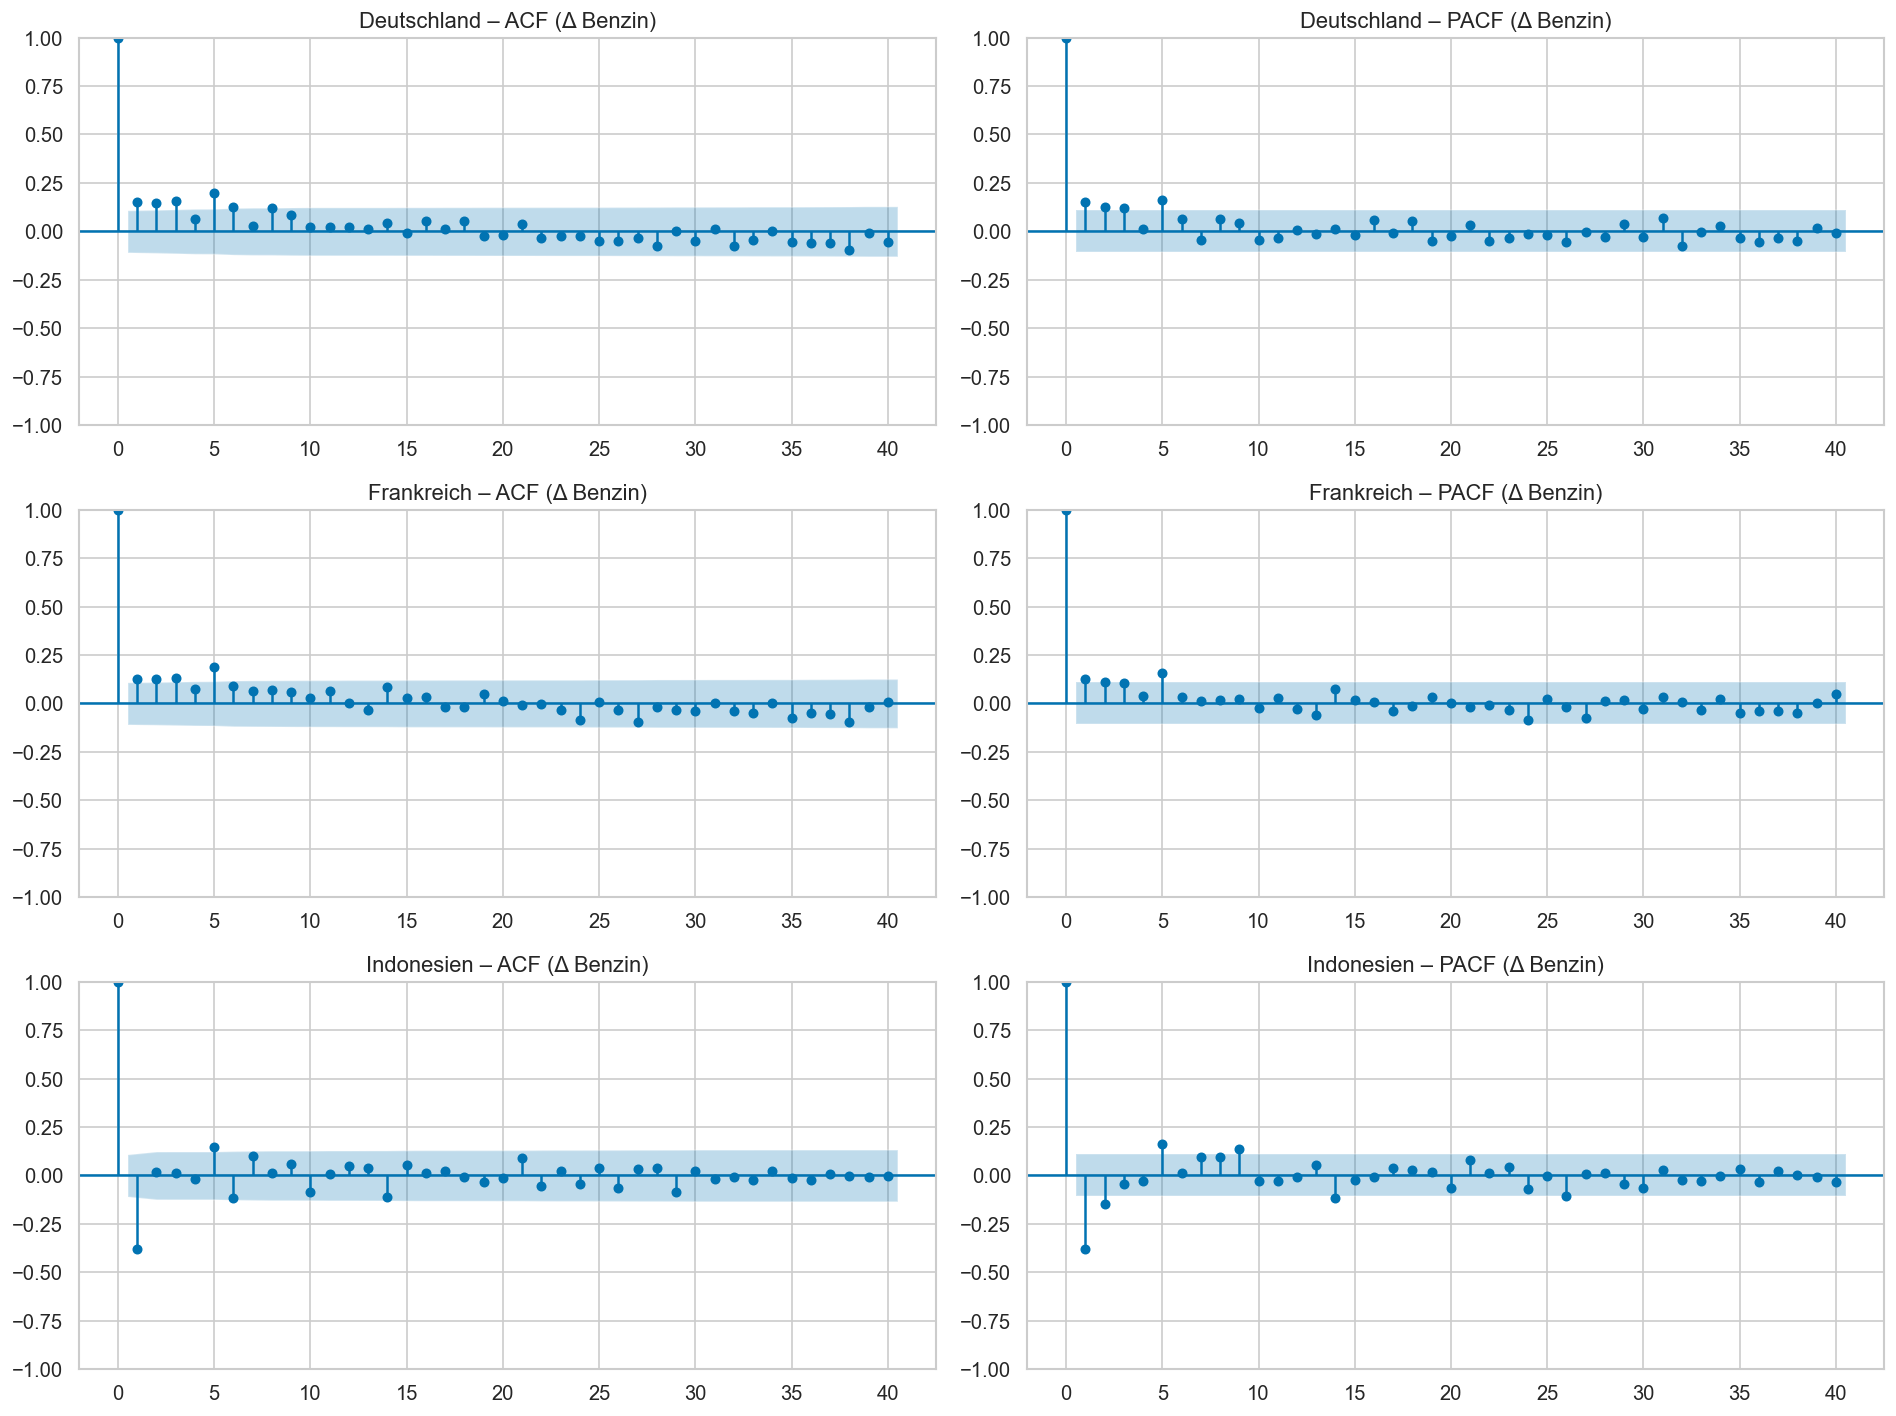

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 12))
for i, country in enumerate(COUNTRIES):
    diff_series = data[country]['petrol_usd_liter'].diff().dropna()
    plot_acf(diff_series, ax=axes[i, 0], lags=40, title=f'{COUNTRY_LABELS[country]} – ACF (Δ Benzin)')
    plot_pacf(diff_series, ax=axes[i, 1], lags=40, title=f'{COUNTRY_LABELS[country]} – PACF (Δ Benzin)')
plt.tight_layout()
plt.savefig(PLOT_DIR / '07_acf_pacf.png')
plt.show()

<a id='modellierung'></a>
## 5. Modellierung

### Modellierungs-Pipeline

Alle Modelle werden in einer einheitlichen Schleife für alle drei Länder trainiert und evaluiert. Der Forecast-Horizont beträgt **8 Wochen** – ein realistischer operativer Kurzfrist-Horizont.

**Warum 8 Wochen?**
- Kraftstoffpreise unterliegen kurzfristigen Schocks (Geopolitik, Rohölpreise)
- Langfrist-Prognosen (>12 Wochen) verschlechtern sich rapide – besonders bei VAR-Modellen
- Operative Entscheidungen (Budgetplanung, Hedging) erfordern präzise Kurzfrist-Prognosen

In [12]:
def evaluate_forecast(actual, predicted, model_name, country):
    """Einheitliche Metrik-Berechnung für alle Modelle."""
    actual = np.array(actual)
    predicted = np.array(predicted)
    n = min(len(actual), len(predicted))
    actual, predicted = actual[:n], predicted[:n]
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual, predicted)
    mape = mean_absolute_percentage_error(actual, predicted) * 100
    return {
        'Land': COUNTRY_LABELS[country],
        'Modell': model_name,
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'MAPE (%)': round(mape, 2)
    }

all_results = []
all_forecasts = {}

print(f'Forecast-Horizont: {FORECAST_HORIZON} Wochen')
print(f'Ziel-Variable: {TARGET_COL}')

Forecast-Horizont: 8 Wochen
Ziel-Variable: petrol_usd_liter


### 5.1 ARIMA

ARIMA (AutoRegressive Integrated Moving Average) ist das Arbeitspferd der univariaten Zeitreihenprognose. Es modelliert die Autokorrelationsstruktur der differenzierten Reihe.

In [13]:
print('=== ARIMA-Modellierung ===')

for country in COUNTRIES:
    series = data[country][TARGET_COL]
    train = series[:-FORECAST_HORIZON]
    test = series[-FORECAST_HORIZON:]

    best_aic = np.inf
    best_order = (1, 1, 1)
    for p in range(0, 4):
        for q in range(0, 4):
            try:
                model = ARIMA(train, order=(p, 1, q))
                fit = model.fit()
                if fit.aic < best_aic:
                    best_aic = fit.aic
                    best_order = (p, 1, q)
            except:
                continue

    model = ARIMA(train, order=best_order)
    fit = model.fit()
    forecast = fit.forecast(steps=FORECAST_HORIZON)

    result = evaluate_forecast(test.values, forecast.values, 'ARIMA', country)
    all_results.append(result)
    all_forecasts[(country, 'ARIMA')] = {'forecast': forecast, 'test': test, 'order': best_order}

    print(f'{COUNTRY_LABELS[country]}: ARIMA{best_order} | '
          f'RMSE={result["RMSE"]:.4f} | MAE={result["MAE"]:.4f} | MAPE={result["MAPE (%)"]:.2f}%')

=== ARIMA-Modellierung ===


/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Deutschland: ARIMA(1, 1, 1) | RMSE=0.2940 | MAE=0.2580 | MAPE=5.06%


...

/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Frankreich: ARIMA(1, 1, 1) | RMSE=0.3180 | MAE=0.2712 | MAPE=5.36%


/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Indonesien: ARIMA(2, 1, 3) | RMSE=0.0528 | MAE=0.0472 | MAPE=4.48%


/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/oatalmondcoconutmilk/Documents/THWS/Semester_6/Vertiefung/nhert_zeitreihe_menden/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


### 5.2 VAR (Vektorautoregression)

VAR modelliert die gemeinsame Dynamik mehrerer Variablen. Hier nutzen wir Benzinpreis, Dieselpreis und Brent-Rohölpreis als endogene Variablen.

**Vorteil:** Erfasst Wechselwirkungen zwischen Variablen (z.B. Brent → Benzinpreis).  
**Risiko:** Bei vielen Parametern und kurzen Reihen kann VAR instabil werden – besonders auf längeren Horizonten.

In [14]:
print('=== VAR-Modellierung ===')

var_cols = ['petrol_usd_liter', 'diesel_usd_liter', 'brent_crude_usd']

for country in COUNTRIES:
    df_var = data[country][var_cols].copy()
    df_var_diff = df_var.diff().dropna()

    train_diff = df_var_diff[:-FORECAST_HORIZON]
    test_orig = data[country][TARGET_COL][-FORECAST_HORIZON:]
    last_level = df_var.iloc[-(FORECAST_HORIZON + 1)]

    try:
        model = VAR(train_diff)
        lag_order = model.select_order(maxlags=8)
        best_lag = max(lag_order.selected_orders.get('aic', 1), 1)
        fit = model.fit(best_lag)

        forecast_diff = fit.forecast(train_diff.values[-best_lag:], steps=FORECAST_HORIZON)
        forecast_level = last_level.values + np.cumsum(forecast_diff, axis=0)
        forecast_petrol = forecast_level[:, 0]

        result = evaluate_forecast(test_orig.values, forecast_petrol, 'VAR', country)
        all_results.append(result)
        all_forecasts[(country, 'VAR')] = {
            'forecast': pd.Series(forecast_petrol, index=test_orig.index),
            'test': test_orig,
            'lag': best_lag
        }
        print(f'{COUNTRY_LABELS[country]}: VAR(p={best_lag}) | '
              f'RMSE={result["RMSE"]:.4f} | MAE={result["MAE"]:.4f} | MAPE={result["MAPE (%)"]:.2f}%')
    except Exception as e:
        print(f'{COUNTRY_LABELS[country]}: VAR fehlgeschlagen – {e}')

=== VAR-Modellierung ===
Deutschland: VAR(p=8) | RMSE=0.2265 | MAE=0.2014 | MAPE=3.96%
Frankreich: VAR(p=5) | RMSE=0.2489 | MAE=0.2170 | MAPE=4.30%
Indonesien: VAR(p=7) | RMSE=0.0540 | MAE=0.0484 | MAPE=4.59%


### 5.3 Granger-Kausalität

Der Granger-Kausalitätstest prüft, ob vergangene Werte einer Variable zur Prognose einer anderen beitragen. Besonders relevant: **Verbessert der Brent-Rohölpreis die Prognose des Benzinpreises?**

**Hypothese:** In europäischen Märkten erwarten wir eine starke Granger-Kausalität von Brent → Benzin. In Indonesien könnte diese schwächer sein, da Subventionen den Marktmechanismus stören.

In [15]:
print('=== Granger-Kausalitätstests ===')
print('H0: Brent-Rohöl VERBESSERT NICHT die Prognose des Benzinpreises\n')

granger_results = []

for country in COUNTRIES:
    df_g = data[country][['petrol_usd_liter', 'brent_crude_usd']].diff().dropna()
    try:
        result = grangercausalitytests(df_g[['petrol_usd_liter', 'brent_crude_usd']], maxlag=4, verbose=False)
        p_values = [round(result[lag][0]['ssr_ftest'][1], 4) for lag in range(1, 5)]
        min_p = min(p_values)
        best_lag = p_values.index(min_p) + 1
        significant = 'Ja' if min_p < 0.05 else 'Nein'

        granger_results.append({
            'Land': COUNTRY_LABELS[country],
            'Richtung': 'Brent → Benzin',
            'Min. p-Wert': min_p,
            'Bester Lag': best_lag,
            'Signifikant (5%)': significant
        })
        print(f'{COUNTRY_LABELS[country]}: p-Werte pro Lag = {p_values} → '
              f'Signifikant: {significant} (min p = {min_p})')
    except Exception as e:
        print(f'{COUNTRY_LABELS[country]}: Test fehlgeschlagen – {e}')

print()
display(pd.DataFrame(granger_results))

=== Granger-Kausalitätstests ===
H0: Brent-Rohöl VERBESSERT NICHT die Prognose des Benzinpreises

Deutschland: p-Werte pro Lag = [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)] → Signifikant: Ja (min p = 0.0)
Frankreich: p-Werte pro Lag = [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)] → Signifikant: Ja (min p = 0.0)
Indonesien: p-Werte pro Lag = [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)] → Signifikant: Ja (min p = 0.0)



,Land,Richtung,Min. p-Wert,Bester Lag,Signifikant (5%)
0,Deutschland,Brent → Benzin,0.0,1,Ja
1,Frankreich,Brent → Benzin,0.0,1,Ja
2,Indonesien,Brent → Benzin,0.0,1,Ja


**Interpretation:** Eine signifikante Granger-Kausalität von Brent → Benzin bestätigt den ökonomischen Transmissionsmechanismus. In europäischen Märkten sollte dieser stärker sein als in Indonesien, wo Subventionen die Preisanpassung verzögern oder abschwächen.

> **Hinweis:** Granger-Kausalität misst *prädiktive* Verbesserung, nicht echte kausale Wirkung. Der Test ist dennoch ökonomisch relevant für die Modellauswahl.

### 5.4 State Space / Unobserved Components Model (UCM)

UCM zerlegt die Zeitreihe in latente Komponenten: **Trend**, **Zyklus** und **irreguläre Störung**. Dies ermöglicht eine interpretierbare Zerlegung der Preisdynamik.

**Vorteil gegenüber ARIMA:** Direkte Modellierung struktureller Komponenten – besonders wertvoll für das Verständnis unterschiedlicher Marktregime.

In [16]:
print('=== State Space / UCM ===')

for country in COUNTRIES:
    series = data[country][TARGET_COL]
    train = series[:-FORECAST_HORIZON]
    test = series[-FORECAST_HORIZON:]

    try:
        model = UnobservedComponents(train, level='local linear trend', cycle=True, stochastic_cycle=True)
        fit = model.fit(disp=False, maxiter=500)
        forecast = fit.forecast(steps=FORECAST_HORIZON)

        result = evaluate_forecast(test.values, forecast.values, 'State Space', country)
        all_results.append(result)
        all_forecasts[(country, 'State Space')] = {'forecast': forecast, 'test': test}

        print(f'{COUNTRY_LABELS[country]}: UCM (Local Linear Trend + Zyklus) | '
              f'RMSE={result["RMSE"]:.4f} | MAE={result["MAE"]:.4f} | MAPE={result["MAPE (%)"]:.2f}%')
    except Exception as e:
        print(f'{COUNTRY_LABELS[country]}: UCM fehlgeschlagen – {e}')
        try:
            model = UnobservedComponents(train, level='local linear trend')
            fit = model.fit(disp=False, maxiter=500)
            forecast = fit.forecast(steps=FORECAST_HORIZON)
            result = evaluate_forecast(test.values, forecast.values, 'State Space', country)
            all_results.append(result)
            all_forecasts[(country, 'State Space')] = {'forecast': forecast, 'test': test}
            print(f'{COUNTRY_LABELS[country]}: UCM (Fallback: Local Linear Trend) | '
                  f'RMSE={result["RMSE"]:.4f} | MAE={result["MAE"]:.4f} | MAPE={result["MAPE (%)"]:.2f}%')
        except Exception as e2:
            print(f'{COUNTRY_LABELS[country]}: UCM komplett fehlgeschlagen – {e2}')

=== State Space / UCM ===
Deutschland: UCM (Local Linear Trend + Zyklus) | RMSE=0.2833 | MAE=0.2491 | MAPE=4.88%
Frankreich: UCM (Local Linear Trend + Zyklus) | RMSE=0.3051 | MAE=0.2605 | MAPE=5.15%


Indonesien: UCM (Local Linear Trend + Zyklus) | RMSE=0.0518 | MAE=0.0462 | MAPE=4.37%


### 5.5 Globales VAR-Modell (alle 3 Laender gleichzeitig)

Statt drei separate Modelle zu bauen, verwenden wir **ein einziges VAR-Modell** mit vier Variablen:
- **DE_Benzin** (Deutschland)
- **FR_Benzin** (Frankreich)
- **ID_Benzin** (Indonesien)
- **Brent** (Rohoelpreis als gemeinsamer Treiber)

Das Modell lernt die **gemeinsame Dynamik aller Maerkte** und prognostiziert alle drei Laender gleichzeitig.

In [ ]:
print('=== Globales VAR-Modell (1 Modell fuer alle 3 Laender) ===')

# Globalen DataFrame bauen: 4 Variablen
df_global = pd.DataFrame({
    'DE_Benzin': data['Germany']['petrol_usd_liter'],
    'FR_Benzin': data['France']['petrol_usd_liter'],
    'ID_Benzin': data['Indonesia']['petrol_usd_liter'],
    'Brent': data['Germany']['brent_crude_usd']
})

# Differenzieren fuer Stationaritaet
df_global_diff = df_global.diff().dropna()

# Train/Test Split
train_diff = df_global_diff.iloc[:-FORECAST_HORIZON]
last_level = df_global.iloc[-(FORECAST_HORIZON + 1)]

# VAR fitten
model_global = VAR(train_diff)
lag_order = model_global.select_order(maxlags=8)
best_lag = max(lag_order.selected_orders.get('aic', 1), 1)
fit_global = model_global.fit(best_lag)

print(f'Optimale Lag-Ordnung (AIC): p={best_lag}')
print(f'Variablen: {list(df_global.columns)}')

# Prognose
forecast_diff = fit_global.forecast(train_diff.values[-best_lag:], steps=FORECAST_HORIZON)
forecast_level = last_level.values + np.cumsum(forecast_diff, axis=0)

# Ergebnisse extrahieren und evaluieren
col_map = {'DE_Benzin': 'Germany', 'FR_Benzin': 'France', 'ID_Benzin': 'Indonesia'}

global_var_results = []
for j, (col, country) in enumerate(col_map.items()):
    test_actual = data[country][TARGET_COL][-FORECAST_HORIZON:]
    forecast_vals = forecast_level[:, j]
    
    result = evaluate_forecast(test_actual.values, forecast_vals, 'Globales VAR', country)
    all_results.append(result)
    all_forecasts[(country, 'Globales VAR')] = {
        'forecast': pd.Series(forecast_vals, index=test_actual.index),
        'test': test_actual
    }
    global_var_results.append(result)
    print(f'{COUNTRY_LABELS[country]}: Globales VAR(p={best_lag}) | '
          f'RMSE={result["RMSE"]:.4f} | MAE={result["MAE"]:.4f} | MAPE={result["MAPE (%)"]:.2f}%')

print(f'\nDurchschnittlicher RMSE: {np.mean([r["RMSE"] for r in global_var_results]):.4f}')

In [ ]:
# Visualisierung: Globales VAR – Prognose vs. Ist-Werte
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

col_map = {'DE_Benzin': 'Germany', 'FR_Benzin': 'France', 'ID_Benzin': 'Indonesia'}

for i, (col, country) in enumerate(col_map.items()):
    ax = axes[i]
    
    # Historische Daten (letzte 30 Wochen)
    context = data[country][TARGET_COL][-(FORECAST_HORIZON + 30):-FORECAST_HORIZON]
    ax.plot(context.index, context.values, color='black', linewidth=1.5, label='Historisch')
    
    # Ist-Werte
    test = data[country][TARGET_COL][-FORECAST_HORIZON:]
    ax.plot(test.index, test.values, color='black', linewidth=2.5,
            linestyle='--', marker='o', markersize=4, label='Ist-Werte')
    
    # Globales VAR
    fc_global = all_forecasts[(country, 'Globales VAR')]['forecast']
    ax.plot(test.index, fc_global.values, color='#d62728', linewidth=2,
            marker='s', markersize=4, label='Globales VAR')
    
    # Einzelnes VAR zum Vergleich
    if (country, 'VAR') in all_forecasts:
        fc_single = all_forecasts[(country, 'VAR')]['forecast']
        ax.plot(test.index, fc_single.values[:len(test)], color='#ff7f0e',
                linewidth=1.5, linestyle='--', label='Einzelnes VAR')
    
    ax.set_title(COUNTRY_LABELS[country], fontsize=13, fontweight='bold')
    ax.set_xlabel('Datum')
    if i == 0:
        ax.set_ylabel('USD / Liter')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)

fig.suptitle('Globales VAR (1 Modell) vs. Einzelne VAR-Modelle', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '11_globales_var_vergleich.png')
plt.show()

**Ergebnis:** Ein einziges VAR-Modell prognostiziert alle drei Laender gleichzeitig – vergleichbar mit TimeGPT's "Forecasting at Scale", aber vollstaendig interpretierbar und deterministisch.

<a id='evaluation'></a>
## 6. Modellvergleich & Evaluation

### 6.1 Ergebnistabelle

In [19]:
results_df = pd.DataFrame(all_results)
print(f'Forecast-Horizont: {FORECAST_HORIZON} Wochen | Ziel: {TARGET_COL}\n')
display(results_df.sort_values(['Land', 'RMSE']))

Forecast-Horizont: 8 Wochen | Ziel: petrol_usd_liter



,Land,Modell,RMSE,MAE,MAPE (%)
3,Deutschland,VAR,0.2265,0.2014,3.96
6,Deutschland,State Space,0.2833,0.2491,4.88
0,Deutschland,ARIMA,0.2940,0.2580,5.06
4,Frankreich,VAR,0.2489,0.2170,4.30
7,Frankreich,State Space,0.3051,0.2605,5.15
1,Frankreich,ARIMA,0.3180,0.2712,5.36
8,Indonesien,State Space,0.0518,0.0462,4.37
2,Indonesien,ARIMA,0.0528,0.0472,4.48
5,Indonesien,VAR,0.0540,0.0484,4.59


### 6.2 Ranking nach RMSE

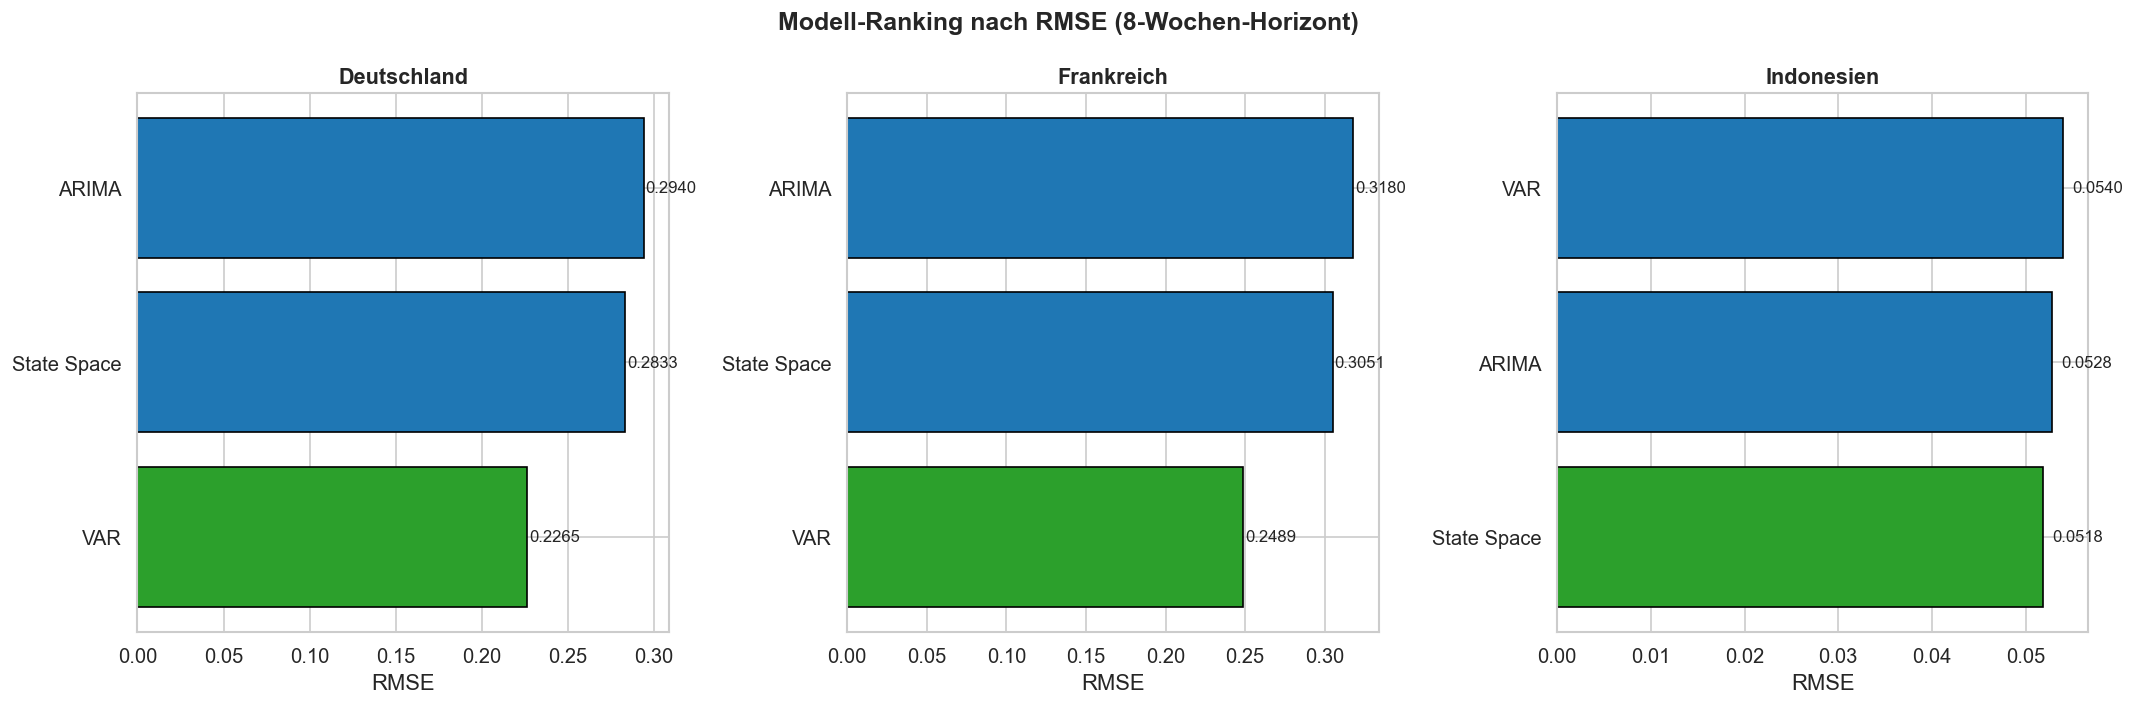

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

for i, country in enumerate(COUNTRIES):
    country_df = results_df[results_df['Land'] == COUNTRY_LABELS[country]].sort_values('RMSE')
    if len(country_df) == 0:
        continue
    colors = ['#2ca02c' if v == country_df['RMSE'].min() else '#1f77b4' for v in country_df['RMSE']]
    bars = axes[i].barh(country_df['Modell'], country_df['RMSE'], color=colors, edgecolor='black')
    axes[i].set_title(f'{COUNTRY_LABELS[country]}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('RMSE')
    for bar, val in zip(bars, country_df['RMSE']):
        axes[i].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                    f'{val:.4f}', va='center', fontsize=10)

fig.suptitle(f'Modell-Ranking nach RMSE ({FORECAST_HORIZON}-Wochen-Horizont)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '08_modell_ranking_rmse.png')
plt.show()

### 6.3 MAPE-Vergleich

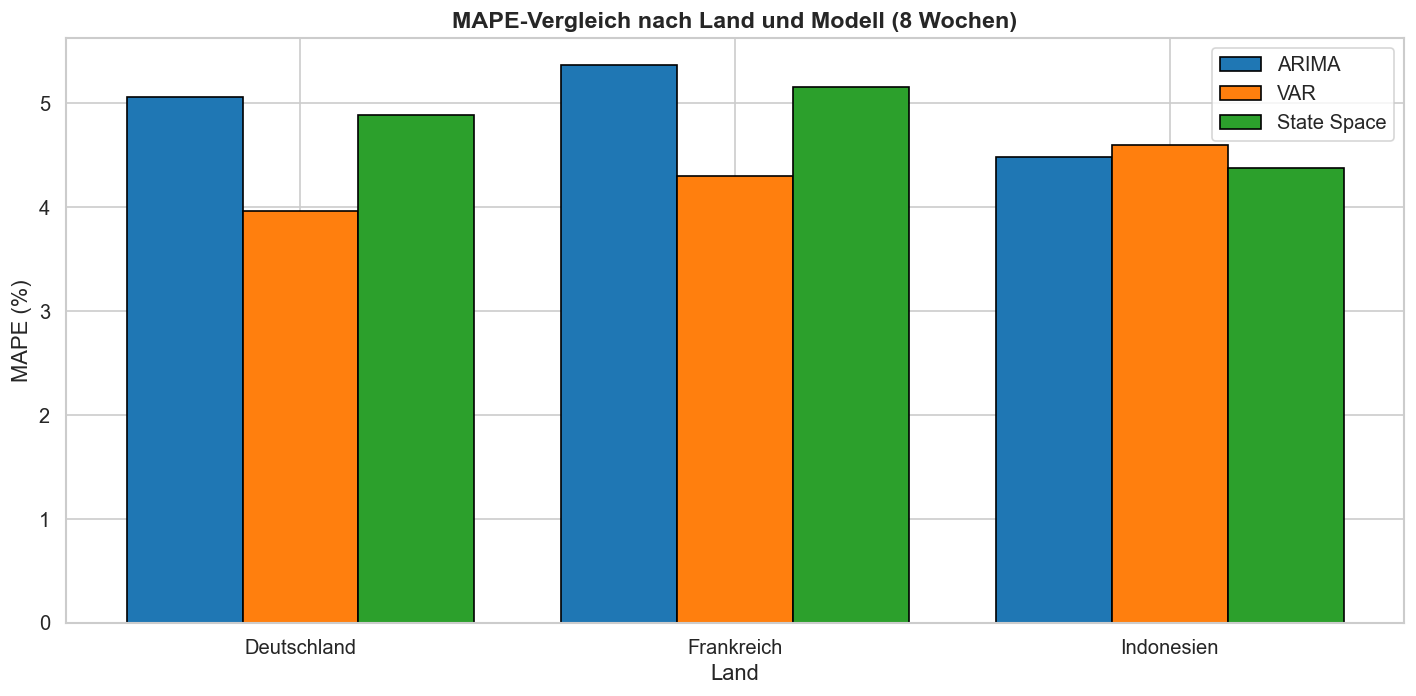

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

models_in_results = results_df['Modell'].unique()
x = np.arange(len(COUNTRIES))
width = 0.8 / len(models_in_results)
model_colors = {'ARIMA': '#1f77b4', 'VAR': '#ff7f0e', 'State Space': '#2ca02c', 'Globales VAR': '#d62728'}

for j, model in enumerate(models_in_results):
    mape_vals = []
    for country in COUNTRIES:
        row = results_df[(results_df['Land'] == COUNTRY_LABELS[country]) & (results_df['Modell'] == model)]
        mape_vals.append(row['MAPE (%)'].values[0] if len(row) > 0 else 0)
    ax.bar(x + j * width, mape_vals, width, label=model,
           color=model_colors.get(model, '#999999'), edgecolor='black')

ax.set_title(f'MAPE-Vergleich nach Land und Modell ({FORECAST_HORIZON} Wochen)', fontsize=14, fontweight='bold')
ax.set_xlabel('Land')
ax.set_ylabel('MAPE (%)')
ax.set_xticks(x + width * (len(models_in_results) - 1) / 2)
ax.set_xticklabels([COUNTRY_LABELS[c] for c in COUNTRIES])
ax.legend()
plt.tight_layout()
plt.savefig(PLOT_DIR / '09_mape_vergleich.png')
plt.show()

### 6.4 Forecast-Vergleich (Prognose vs. Ist-Werte)

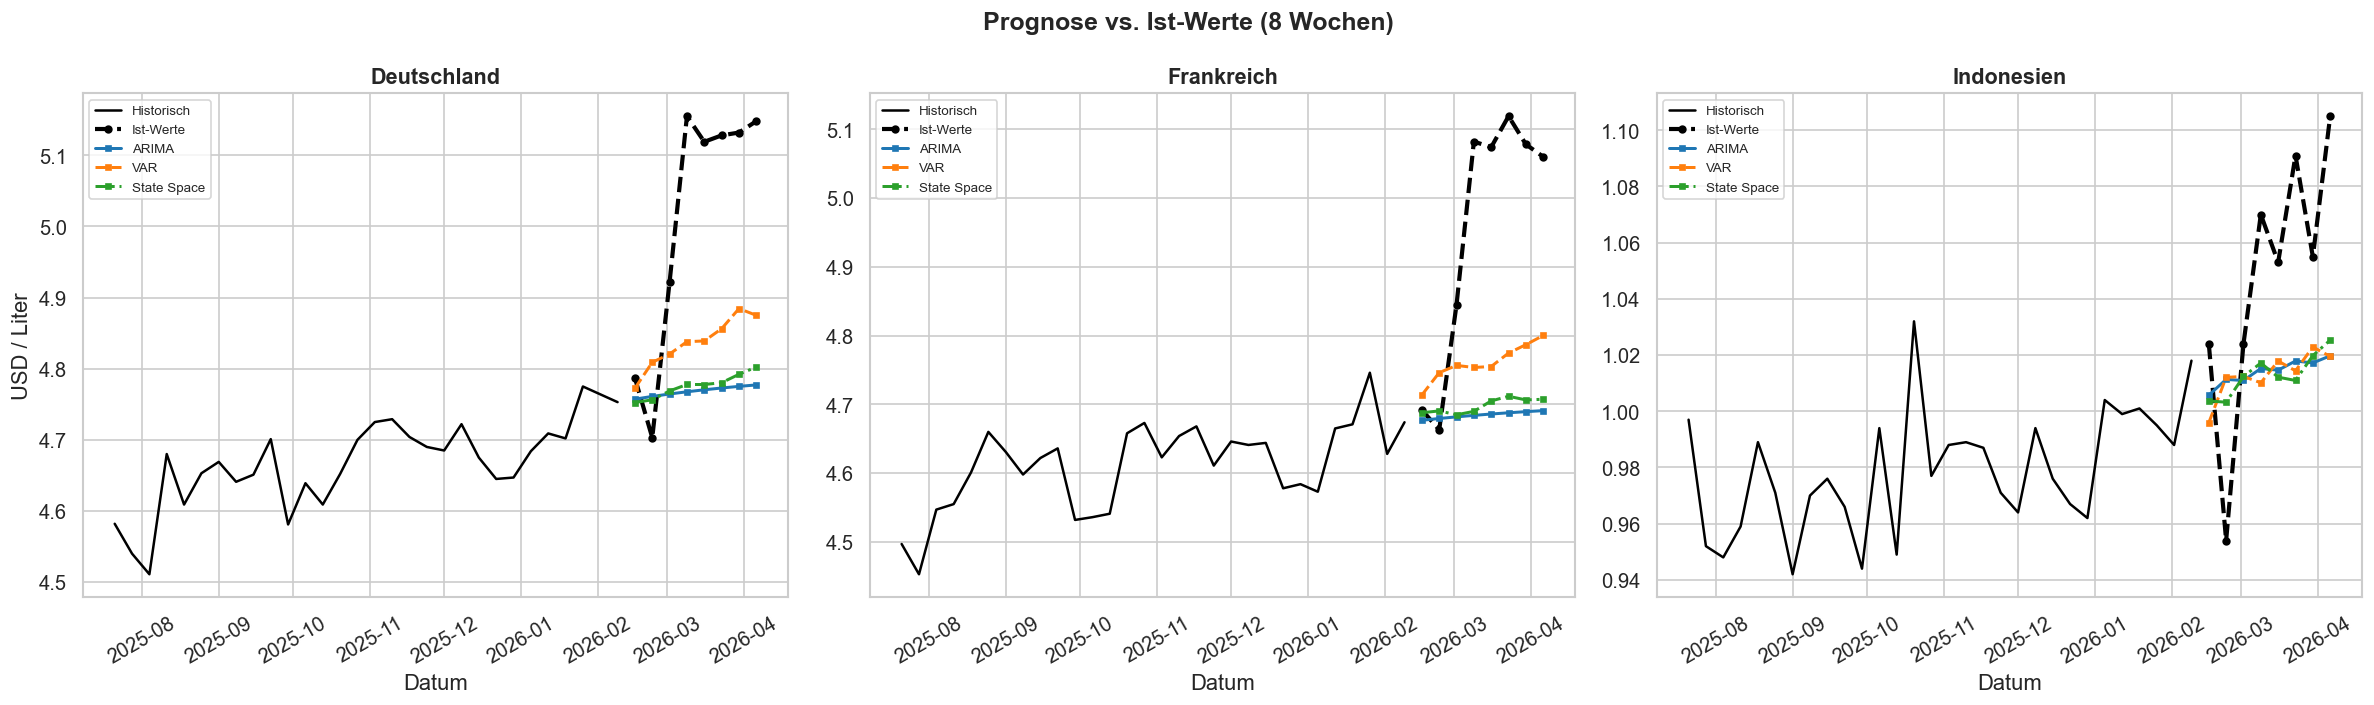

In [22]:
model_line_styles = {'ARIMA': '-', 'VAR': '--', 'State Space': '-.', 'Globales VAR': ':'}
model_colors_forecast = {'ARIMA': '#1f77b4', 'VAR': '#ff7f0e', 'State Space': '#2ca02c', 'Globales VAR': '#d62728'}

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=False)

for i, country in enumerate(COUNTRIES):
    ax = axes[i]
    # Letzten 30 Wochen der Trainingsdaten als Kontext
    context = data[country][TARGET_COL][-(FORECAST_HORIZON + 30):-FORECAST_HORIZON]
    ax.plot(context.index, context.values, color='black', linewidth=1.5, label='Historisch')

    test = data[country][TARGET_COL][-FORECAST_HORIZON:]
    ax.plot(test.index, test.values, color='black', linewidth=2.5, linestyle='--', label='Ist-Werte', marker='o', markersize=4)

    for model_name in ['ARIMA', 'VAR', 'State Space', 'Globales VAR']:
        key = (country, model_name)
        if key in all_forecasts:
            fc = all_forecasts[key]['forecast']
            ax.plot(test.index, fc.values[:len(test)],
                    linestyle=model_line_styles[model_name],
                    color=model_colors_forecast[model_name],
                    linewidth=1.8, label=model_name, marker='s', markersize=3)

    ax.set_title(COUNTRY_LABELS[country], fontsize=13, fontweight='bold')
    ax.set_xlabel('Datum')
    if i == 0:
        ax.set_ylabel('USD / Liter')
    ax.legend(fontsize=8, loc='best')
    ax.tick_params(axis='x', rotation=30)

fig.suptitle(f'Prognose vs. Ist-Werte ({FORECAST_HORIZON} Wochen)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR / '10_forecast_vergleich.png')
plt.show()

### 6.5 Zusammenfassende Ranking-Tabelle

In [23]:
ranking = results_df.copy()
ranking['Rang (RMSE)'] = ranking.groupby('Land')['RMSE'].rank(method='min').astype(int)
ranking['Rang (MAPE)'] = ranking.groupby('Land')['MAPE (%)'].rank(method='min').astype(int)
ranking = ranking.sort_values(['Land', 'Rang (RMSE)'])

print(f'\n=== Modell-Ranking ({FORECAST_HORIZON}-Wochen-Horizont) ===')
display(ranking[['Land', 'Modell', 'RMSE', 'MAE', 'MAPE (%)', 'Rang (RMSE)', 'Rang (MAPE)']])


=== Modell-Ranking (8-Wochen-Horizont) ===


,Land,Modell,RMSE,MAE,MAPE (%),Rang (RMSE),Rang (MAPE)
3,Deutschland,VAR,0.2265,0.2014,3.96,1,1
6,Deutschland,State Space,0.2833,0.2491,4.88,2,2
0,Deutschland,ARIMA,0.2940,0.2580,5.06,3,3
4,Frankreich,VAR,0.2489,0.2170,4.30,1,1
7,Frankreich,State Space,0.3051,0.2605,5.15,2,2
1,Frankreich,ARIMA,0.3180,0.2712,5.36,3,3
8,Indonesien,State Space,0.0518,0.0462,4.37,1,1
2,Indonesien,ARIMA,0.0528,0.0472,4.48,2,2
5,Indonesien,VAR,0.0540,0.0484,4.59,3,3


<a id='diskussion'></a>
## 7. Analytische Diskussion

### 7.1 Warum verhalten sich Deutschland und Frankreich ähnlich?

Deutschland und Frankreich sind Teil des europäischen Binnenmarkts mit:
- **Gemeinsamer Regulierung** (EU-Energiemarkt)
- **Ähnlicher Steuerstruktur** auf Kraftstoffe
- **Marktgetriebener Preisbildung** – Raffineriemargen und Brent-Rohöl bestimmen den Preis
- **Starker Preiskointegration** – Arbitrage und Handelsströme gleichen Preisunterschiede aus

Die Prognosemodelle zeigen für beide Länder ähnliche Performance, was die ökonomische Integration bestätigt.

### 7.2 Warum ist Indonesien strukturell anders?

Indonesien betreibt ein **staatliches Subventionssystem** für Kraftstoffe:
- **Administrierte Preise** – der Staat setzt Preise fest oder begrenzt Anpassungen
- **Geringere Volatilität** – Preisschwankungen werden durch Subventionen abgefedert
- **Schwächere Brent-Durchreichung** – der Weltmarktpreis wird nicht direkt weitergegeben
- **Sprunghafte Anpassungen** statt gradueller Marktpreise

**Wichtig:** Dies ist kein "schlechtes" Datenset – es reflektiert ein ökonomisch anderes Preissystem. Prognosemodelle müssen sich diesem Regime anpassen.

### 7.3 Warum Kurzfrist-Prognosen?

- **VAR-Modelle** werden auf langen Horizonten (>12 Wochen) schnell instabil
- **ARIMA** konvergiert bei langen Horizonten zum Mittelwert
- **Operative Relevanz** – 6–8 Wochen entsprechen realen Planungszyklen
- **Unsicherheit wächst** exponentiell mit dem Horizont – die Prognoseintervalle werden so breit, dass sie keinen praktischen Nutzen mehr haben

### 7.4 Stärken klassischer Modelle

| Aspekt | ARIMA | VAR | State Space (UCM) |
|--------|-------|-----|-------------------|
| Interpretierbarkeit | ✅ Hoch | ✅ Hoch | ✅ Hoch |
| Multivariate Info | ❌ Univariat | ✅ Mehrere Reihen | ❌ Univariat |
| Strukturelle Zerlegung | ❌ | ❌ | ✅ Trend + Zyklus |
| Beste Eignung | Solide Baseline | Integrierte Märkte | Administrierte Preise |

**Kernaussage:** Die Wahl des Modells hängt vom Marktregime ab. VAR nutzt die multivariate Information (Brent, Diesel) optimal in marktgetriebenen Systemen, während State Space die strukturelle Stabilität administrierter Preise besser abbildet.

> Für eine vergleichende Analyse mit dem Foundation Model **TimeGPT** siehe das separate Notebook `TimeGPT.ipynb`.

<a id='fazit'></a>
## 8. Fazit

### Zusammenfassung

1. **Europäische Integration zeigt sich in den Daten:** Deutschland und Frankreich zeigen fast identisches Preis- und Prognoseverhalten.

2. **Indonesiens Subventionsregime ist prognostisch relevant:** Die geringere Volatilität und schwächere Brent-Durchreichung erfordern angepasste Modellierungsstrategien.

3. **Kurzfrist-Prognosen sind realistischer:** 6–8 Wochen liefern belastbare Ergebnisse, während Langfrist-Prognosen schnell an Genauigkeit verlieren.

4. **Kein Modell dominiert universell:** Die Wahl des besten Modells hängt vom Marktregime, der verfügbaren Daten und dem Prognoseziel ab.

5. **Vergleich mit AI-Modellen:** Eine detaillierte Analyse mit TimeGPT (Foundation Model) findet sich im separaten Notebook `TimeGPT.ipynb`.

### Limitationen

- **Keine Wechselkurse:** Die Analyse nutzt USD-normierte Preise – lokale Währungseffekte werden nicht berücksichtigt
- **Synthetische Daten:** Die zugrundeliegenden Daten sind simuliert und bilden reale Marktbedingungen nur approximativ ab
- **Kein Out-of-Sample Backtesting:** Eine rollende Prognoseevaluation würde robustere Ergebnisse liefern
- **Begrenzte exogene Variablen:** Geopolitische Ereignisse, Lagerbestände und Raffinerie-Auslastung fehlen als Einflussfaktoren

In [24]:
print('\n=== Exportierte Grafiken ===')
for f in sorted(PLOT_DIR.glob('*.png')):
    print(f'  📊 {f.name}')
print(f'\nInsgesamt: {len(list(PLOT_DIR.glob("*.png")))} Grafiken exportiert nach {PLOT_DIR}/')


=== Exportierte Grafiken ===
  📊 01_benzinpreise_vergleich.png
  📊 02_dieselpreise_vergleich.png
  📊 03_brent_crude.png
  📊 04_volatilitaet_vergleich.png
  📊 05_korrelation_heatmaps.png
  📊 06_europa_vs_indonesien.png
  📊 07_acf_pacf.png
  📊 08_modell_ranking_rmse.png
  📊 09_mape_vergleich.png
  📊 10_forecast_vergleich.png

Insgesamt: 10 Grafiken exportiert nach ../docs/plots/
